# Análise de Indicadores de Saúde Pública no Brasil (2015–2024)
**Disciplina:** Linguagem de Programação — Análise e Visualização de Dados com Python  
**Aluno:** Yago Baltazar Ferreira  
**Professor:** Alexandre Neves Louzada

## 1. Introdução
Este notebook investiga indicadores de saúde pública no Brasil entre 2015 e 2024 a partir de uma base **simulada** fornecida pelo professor. O objetivo é analisar a evolução dos indicadores, comparar regiões e estados, avaliar a capacidade hospitalar e identificar as áreas mais vulneráveis.

**Perguntas orientadoras**
- Quais regiões apresentam maiores índices de mortalidade?
- Houve melhoria nos indicadores ao longo do tempo?
- Existem desigualdades regionais?
- Quais estados possuem maior taxa de internação?
- Existe relação entre vacinação e redução de doenças?
- Como evoluiu a expectativa de vida?
- Quais indicadores apresentam maior criticidade?

## 2. Contextualização da saúde pública
Indicadores de saúde pública avaliam a qualidade de vida da população e apoiam decisões de governo. Mortalidade e expectativa de vida mostram o resultado final da saúde, vacinação mostra a prevenção e médicos e leitos mostram a infraestrutura disponível.

## 3. Explicação da base
Arquivo: `simulacao_saude_publica_brasil.csv` (4.440 linhas, 14 colunas), com 37 municípios de 20 estados, de janeiro de 2015 a dezembro de 2024.

| Coluna | Descrição |
|---|---|
| ano, mes, data | Período da medição |
| regiao, uf, municipio | Localização |
| expectativa_vida | Expectativa de vida (anos) |
| taxa_mortalidade | Taxa de mortalidade |
| taxa_internacao | Taxa de internação |
| cobertura_vacinal | Percentual de vacinação |
| medicos_por_1000 | Médicos por 1000 habitantes |
| leitos_hospitalares | Quantidade de leitos |
| casos_doencas_cronicas | Quantidade estimada de casos |
| nivel_criticidade | Baixo, Médio, Alto ou Crítico |

## 4. Leitura dos dados

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../dados/simulacao_saude_publica_brasil.csv", encoding="utf-8-sig")
df.head()

,ano,mes,data,regiao,uf,municipio,expectativa_vida,taxa_mortalidade,taxa_internacao,cobertura_vacinal,medicos_por_1000,leitos_hospitalares,casos_doencas_cronicas,nivel_criticidade
0,2015,1,2015-01-01,Norte,AM,Manaus,69.9,7.25,59.37,55.88,2.30,566,56400,Alto
1,2015,1,2015-01-01,Norte,PA,Belém,71.6,6.10,100.28,68.56,0.94,9478,90326,Baixo
2,2015,1,2015-01-01,Norte,PA,Santarém,76.8,11.05,80.91,57.28,3.68,6539,199254,Alto
3,2015,1,2015-01-01,Norte,RO,Porto Velho,70.7,4.32,76.32,76.93,3.76,6025,126939,Médio
4,2015,1,2015-01-01,Norte,TO,Palmas,71.1,5.60,70.61,51.93,3.52,2957,170250,Alto


In [18]:
print(df.shape)
df.info()

(4440, 14)
<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ano                     4440 non-null   int64  
 1   mes                     4440 non-null   int64  
 2   data                    4440 non-null   str    
 3   regiao                  4440 non-null   str    
 4   uf                      4440 non-null   str    
 5   municipio               4440 non-null   str    
 6   expectativa_vida        4440 non-null   float64
 7   taxa_mortalidade        4440 non-null   float64
 8   taxa_internacao         4440 non-null   float64
 9   cobertura_vacinal       4440 non-null   float64
 10  medicos_por_1000        4440 non-null   float64
 11  leitos_hospitalares     4440 non-null   int64  
 12  casos_doencas_cronicas  4440 non-null   int64  
 13  nivel_criticidade       4440 non-null   str    
dtypes: float64(5), int64(4), str(5)
memory u

In [19]:
df.describe().round(2)

,ano,mes,expectativa_vida,taxa_mortalidade,taxa_internacao,cobertura_vacinal,medicos_por_1000,leitos_hospitalares,casos_doencas_cronicas
count,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00
mean,2019.50,6.50,73.47,7.98,110.69,73.71,2.38,5963.41,101285.15
std,2.87,3.45,3.16,2.35,40.48,13.92,0.92,3421.48,57587.45
min,2015.00,1.00,68.00,4.01,40.10,50.00,0.80,103.00,1037.00
25%,2017.00,3.75,70.70,5.91,75.54,61.52,1.58,2976.25,50911.50
50%,2019.50,6.50,73.40,8.02,111.50,73.70,2.36,5918.00,102154.50
75%,2022.00,9.25,76.20,10.05,145.69,85.51,3.17,8927.00,150505.75
max,2024.00,12.00,79.00,12.00,180.00,97.98,4.00,11997.00,199999.00


## 5. Limpeza e preparação

In [20]:
print("Valores ausentes:", df.isna().sum().sum())
print("Linhas duplicadas:", df.duplicated().sum())
print("Regiões:", sorted(df["regiao"].unique()))
print("Níveis de criticidade:", df["nivel_criticidade"].unique())

df["data"] = pd.to_datetime(df["data"])
ordem = ["Baixo", "Médio", "Alto", "Crítico"]
df["nivel_criticidade"] = pd.Categorical(df["nivel_criticidade"], categories=ordem, ordered=True)

colunas_indicadores = ["expectativa_vida", "taxa_mortalidade", "taxa_internacao", "cobertura_vacinal",
                       "medicos_por_1000", "leitos_hospitalares", "casos_doencas_cronicas"]
df[colunas_indicadores].describe().loc[["min", "max"]]

Valores ausentes: 0
Linhas duplicadas: 0
Regiões: ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']
Níveis de criticidade: <StringArray>
['Alto', 'Baixo', 'Médio', 'Crítico']
Length: 4, dtype: str


,expectativa_vida,taxa_mortalidade,taxa_internacao,cobertura_vacinal,medicos_por_1000,leitos_hospitalares,casos_doencas_cronicas
min,68.0,4.01,40.1,50.00,0.8,103.0,1037.0
max,79.0,12.00,180.0,97.98,4.0,11997.0,199999.0


A base está limpa: não há valores ausentes nem duplicados, e os valores estão em faixas plausíveis (por exemplo, cobertura vacinal abaixo de 100%). As principais etapas foram converter a coluna `data` para data e ordenar o nível de criticidade.

## 6. Engenharia de atributos

In [21]:
df["criticidade_num"] = df["nivel_criticidade"].map({"Baixo": 1, "Médio": 2, "Alto": 3, "Crítico": 4}).astype(int)
df["periodo"] = np.where(df["ano"] <= 2019, "2015-2019", "2020-2024")

def normalizar(serie):
    return (serie - serie.min()) / (serie.max() - serie.min())

por_uf = df.groupby(["uf", "regiao"])[colunas_indicadores].mean().reset_index()
por_uf["indice_vulnerabilidade"] = (
    normalizar(por_uf["taxa_mortalidade"]) + normalizar(por_uf["taxa_internacao"])
    + (1 - normalizar(por_uf["cobertura_vacinal"])) + (1 - normalizar(por_uf["expectativa_vida"]))
    + (1 - normalizar(por_uf["medicos_por_1000"]))
) / 5
ranking = por_uf.sort_values("indice_vulnerabilidade", ascending=False)
ranking[["uf", "regiao", "indice_vulnerabilidade"]].round(3).head(10)

,uf,regiao,indice_vulnerabilidade
8,MS,Centro-Oeste,0.873
14,RJ,Sudeste,0.719
7,MG,Sudeste,0.685
16,RS,Sul,0.667
2,CE,Nordeste,0.647
12,PE,Nordeste,0.624
13,PR,Sul,0.622
5,GO,Centro-Oeste,0.619
18,SP,Sudeste,0.553
9,MT,Centro-Oeste,0.520


O **índice de vulnerabilidade** (0 a 1) combina cinco indicadores já normalizados: mortalidade e internação altas, e vacinação, expectativa de vida e médicos baixos. Quanto maior, mais vulnerável o estado.

## 7. KPIs

In [22]:
print(f"Expectativa média de vida: {df['expectativa_vida'].mean():.1f} anos")
print(f"Taxa média de mortalidade: {df['taxa_mortalidade'].mean():.2f}")
print(f"Cobertura vacinal média: {df['cobertura_vacinal'].mean():.1f}%")
print(f"Estado mais vulnerável: {ranking.iloc[0]['uf']} ({ranking.iloc[0]['regiao']})")
print(f"Média de leitos hospitalares: {df['leitos_hospitalares'].mean():,.0f}")
print(f"Total de internações (soma das taxas): {df['taxa_internacao'].sum():,.0f}")

Expectativa média de vida: 73.5 anos
Taxa média de mortalidade: 7.98
Cobertura vacinal média: 73.7%
Estado mais vulnerável: MS (Centro-Oeste)
Média de leitos hospitalares: 5,963
Total de internações (soma das taxas): 491,459


## 8. Visualizações

### 8.1 Evolução temporal

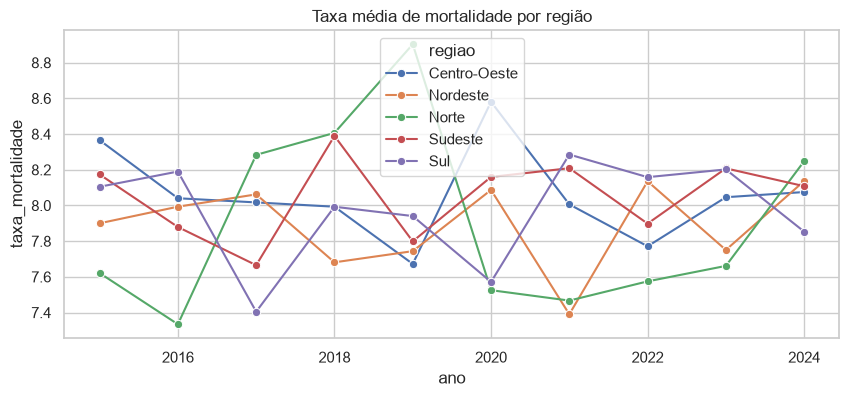

In [23]:
por_ano = df.groupby(["ano", "regiao"])["taxa_mortalidade"].mean().reset_index()
plt.figure(figsize=(10, 4))
sns.lineplot(data=por_ano, x="ano", y="taxa_mortalidade", hue="regiao", marker="o")
plt.title("Taxa média de mortalidade por região")
plt.show()

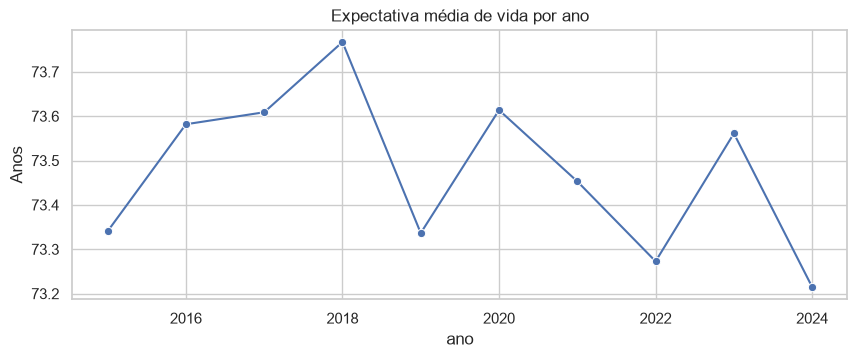

ano
2015    73.34
2016    73.58
2017    73.61
2018    73.77
2019    73.34
2020    73.61
2021    73.45
2022    73.27
2023    73.56
2024    73.21
Name: expectativa_vida, dtype: float64

In [24]:
vida_ano = df.groupby("ano")["expectativa_vida"].mean()
plt.figure(figsize=(10, 3.5))
sns.lineplot(x=vida_ano.index, y=vida_ano.values, marker="o")
plt.title("Expectativa média de vida por ano")
plt.ylabel("Anos")
plt.show()
vida_ano.round(2)

### 8.2 Comparação entre regiões e estados

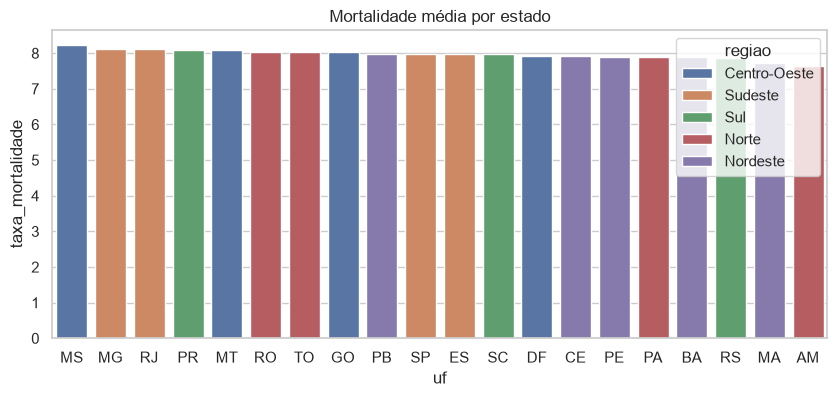

In [25]:
mort_uf = df.groupby(["uf", "regiao"])["taxa_mortalidade"].mean().reset_index().sort_values("taxa_mortalidade", ascending=False)
plt.figure(figsize=(10, 4))
sns.barplot(data=mort_uf, x="uf", y="taxa_mortalidade", hue="regiao", dodge=False)
plt.title("Mortalidade média por estado")
plt.show()

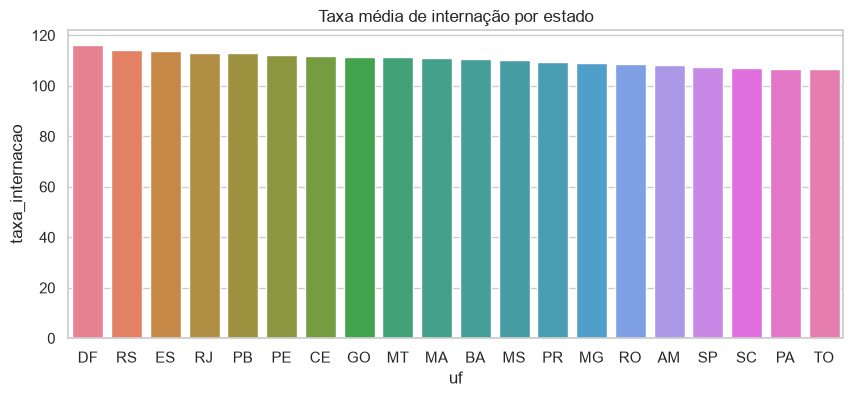

In [26]:
int_uf = df.groupby("uf")["taxa_internacao"].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 4))
sns.barplot(data=int_uf, x="uf", y="taxa_internacao", hue="uf", legend=False)
plt.title("Taxa média de internação por estado")
plt.show()

### 8.3 Infraestrutura hospitalar

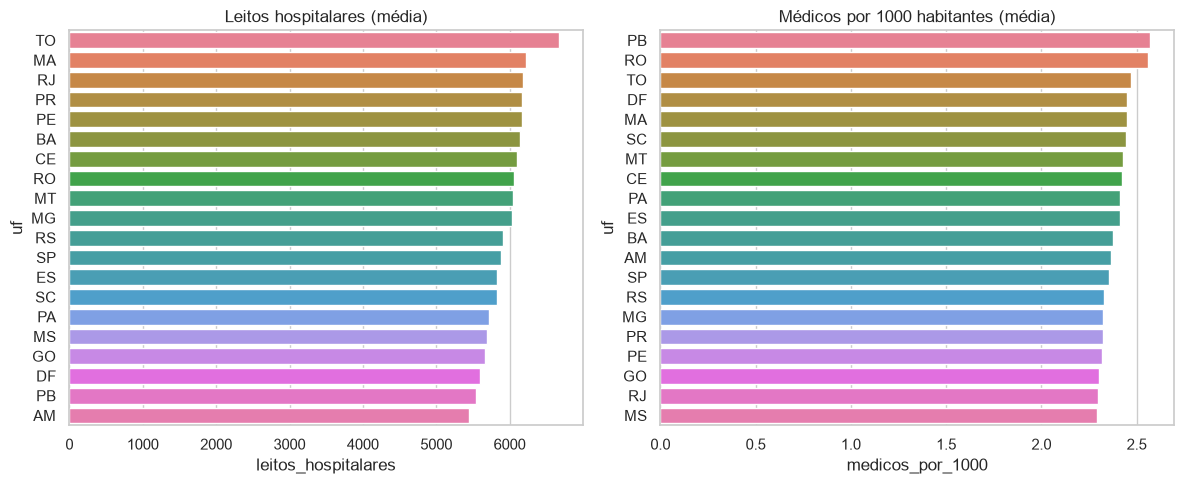

In [27]:
infra = df.groupby("uf")[["leitos_hospitalares", "medicos_por_1000"]].mean().reset_index()
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=infra.sort_values("leitos_hospitalares", ascending=False), y="uf", x="leitos_hospitalares", hue="uf", legend=False, ax=eixos[0])
sns.barplot(data=infra.sort_values("medicos_por_1000", ascending=False), y="uf", x="medicos_por_1000", hue="uf", legend=False, ax=eixos[1])
eixos[0].set_title("Leitos hospitalares (média)")
eixos[1].set_title("Médicos por 1000 habitantes (média)")
plt.tight_layout()
plt.show()

### 8.4 Análise epidemiológica

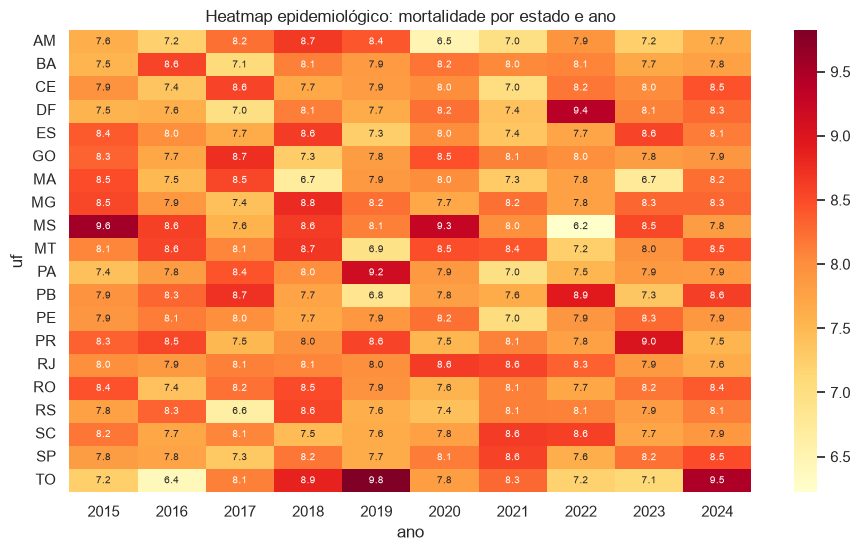

In [28]:
tabela = df.pivot_table(index="uf", columns="ano", values="taxa_mortalidade", aggfunc="mean")
plt.figure(figsize=(11, 6))
sns.heatmap(tabela, annot=True, fmt=".1f", cmap="YlOrRd", annot_kws={"size": 7})
plt.title("Heatmap epidemiológico: mortalidade por estado e ano")
plt.show()

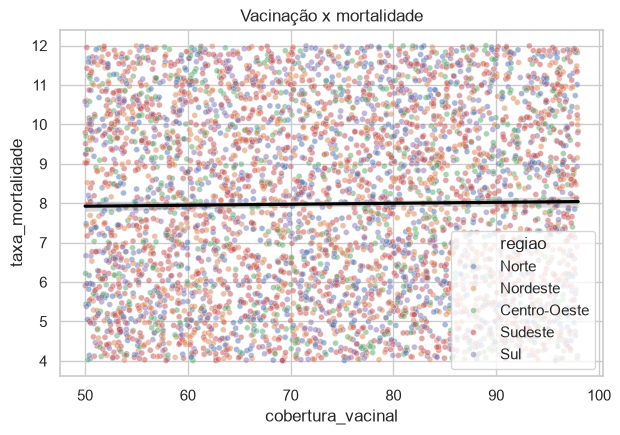

Correlação: 0.015


In [29]:
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=df, x="cobertura_vacinal", y="taxa_mortalidade", hue="regiao", alpha=0.5, s=18)
sns.regplot(data=df, x="cobertura_vacinal", y="taxa_mortalidade", scatter=False, color="black")
plt.title("Vacinação x mortalidade")
plt.show()
print("Correlação:", round(df["cobertura_vacinal"].corr(df["taxa_mortalidade"]), 3))

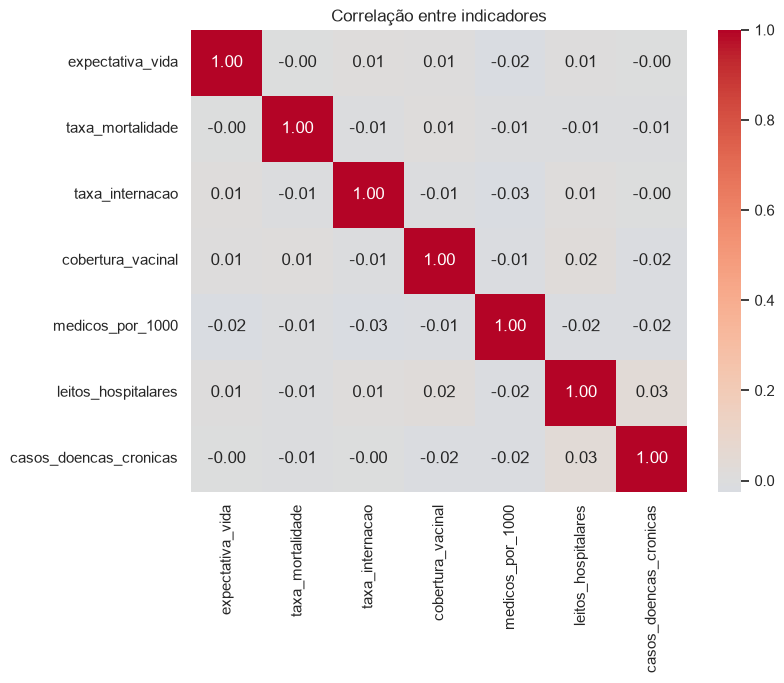

In [30]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[colunas_indicadores].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre indicadores")
plt.show()

### 8.5 Criticidade

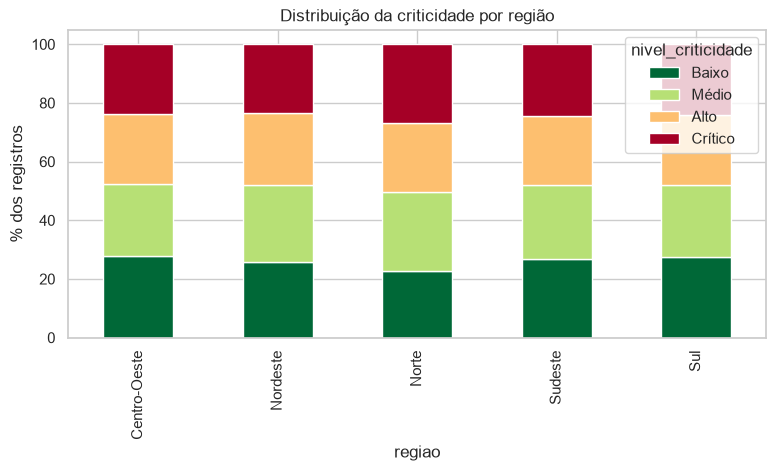

nivel_criticidade,Baixo,Médio,Alto,Crítico
regiao,,,,
Centro-Oeste,27.8,24.7,23.7,23.8
Nordeste,25.7,26.1,24.8,23.3
Norte,22.8,26.8,23.5,26.8
Sudeste,26.8,25.4,23.5,24.3
Sul,27.4,24.6,23.9,24.2


In [31]:
prop = df.groupby(["regiao", "nivel_criticidade"], observed=True).size().unstack(fill_value=0)
prop = prop.div(prop.sum(axis=1), axis=0) * 100
prop.plot(kind="bar", stacked=True, colormap="RdYlGn_r", figsize=(9, 4))
plt.ylabel("% dos registros")
plt.title("Distribuição da criticidade por região")
plt.show()
prop.round(1)

### 8.6 Tabela dinâmica

In [32]:
df.pivot_table(index="regiao", columns="nivel_criticidade", values="taxa_mortalidade", aggfunc="mean", observed=True).round(2)

nivel_criticidade,Baixo,Médio,Alto,Crítico
regiao,,,,
Centro-Oeste,7.98,8.11,8.08,8.07
Nordeste,7.86,7.91,7.91,7.88
Norte,7.73,7.87,7.84,8.13
Sudeste,8.00,8.07,8.21,7.92
Sul,8.00,8.25,8.01,7.61


## 9. Interpretação dos resultados
- **Mortalidade por região:** as médias regionais são muito próximas (entre 7,9 e 8,1), então não há desigualdade regional marcante. Por estado, a maior média é de MS e a menor é de AM.
- **Evolução temporal:** a expectativa média de vida oscila entre 73,2 e 73,8 anos sem tendência clara de melhora ou piora. Os demais indicadores também variam pouco de um ano para outro.
- **Internação:** o DF tem a maior taxa média de internação e TO a menor.
- **Vacinação x mortalidade:** a correlação é praticamente zero (cerca de 0,02). Nesta base simulada, não há evidência de que mais vacinação reduza a mortalidade. Isso difere do que se espera na realidade, e acontece porque os dados são simulados.
- **Infraestrutura:** leitos e médicos variam entre estados, mas não se relacionam com internação nem com mortalidade.
- **Criticidade:** cerca de 24% dos registros são Críticos, distribuídos de forma semelhante entre as regiões.
- **Estado mais vulnerável:** pelo índice, MS aparece no topo, mas o índice compara estados que são parecidos entre si, então a diferença deve ser lida com cautela.

## 10. Conclusão
A base simulada mostra indicadores bastante homogêneos entre regiões e ao longo dos anos, sem relações fortes entre as variáveis. O principal aprendizado é metodológico: construir KPIs, um índice de vulnerabilidade e visualizações comparativas permite identificar onde olhar primeiro (estados no topo do ranking de vulnerabilidade) e também reconhecer quando os dados **não** sustentam uma conclusão, como a relação entre vacinação e mortalidade.

Como próximos passos, o ideal seria repetir a análise com dados reais (por exemplo, DATASUS e IBGE) e incluir populações para calcular taxas absolutas de internação.

*Observação: base simulada, apenas para fins educacionais.*